In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
sys.path.append(f"./../")

# Import the BWT module
from src.bwt import QuantumWalkBWT, compare_theory_numerical, analyze_scaling

In [2]:
# Create output directory
output_dir = "bwt_results"
os.makedirs(output_dir, exist_ok=True)

# Set the random seed for reproducibility
np.random.seed(42)

def main():
    """Main function to run the quantum walk simulations"""
    print("=" * 50)
    print("BWT Quantum Walk Simulation")
    print("=" * 50)
    
    # Run simulation for a single tree height
    height = 3
    print(f"\nRunning detailed simulation for height = {height}...")
    result = compare_theory_numerical(height=height)
    
    # Save probability plot
    result['probability_plot'].savefig(f"{output_dir}/bwt_exit_probability_h{height}.pdf")
    print(f"Saved exit probability plot to {output_dir}/bwt_exit_probability_h{height}.pdf")
    
    # Save quantum state visualizations
    for t, vis_fig in result['state_visualizations']:
        filename = f"{output_dir}/bwt_state_h{height}_t{t:.2f}.pdf"
        vis_fig.savefig(filename)
        print(f"Saved state visualization at t = {t:.2f} to {filename}")
        plt.close(vis_fig)
    
    # Close probability plot figure
    plt.close(result['probability_plot'])
    
    # Run scaling analysis for multiple heights
    print("\nRunning scaling analysis for multiple tree heights...")
    heights = [2, 3, 4]  # Can add 5 for more comprehensive analysis, but it takes longer
    scaling_fig, scaling_results = analyze_scaling(heights=heights)
    
    # Save scaling figure
    scaling_fig.savefig(f"{output_dir}/bwt_scaling_analysis.pdf")
    print(f"Saved scaling analysis to {output_dir}/bwt_scaling_analysis.pdf")
    plt.close(scaling_fig)
    
    # Generate comparison plot of actual quantum state evolution vs theoretical prediction
    print("\nGenerating comparison of quantum state evolution...")
    generate_quantum_state_comparison(height=3)
    
    print("\nSimulation complete! All results saved to", output_dir)

def generate_quantum_state_comparison(height=3):
    """Generate a side-by-side comparison of quantum state evolution and theoretical prediction"""
    qwalk = QuantumWalkBWT(height=height)
    optimal_t = np.pi * (2*height+1) / 2
    
    # Create a grid of times to visualize
    times = [
        0,                  # Initial state
        optimal_t * 0.25,   # 25% of optimal time
        optimal_t * 0.5,    # 50% of optimal time
        optimal_t * 0.75,   # 75% of optimal time
        optimal_t,          # Optimal time
        optimal_t * 1.25    # 125% of optimal time
    ]
    
    # Create a 2x3 grid of subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f"Quantum State Evolution on BWT (height = {height})", fontsize=16)
    
    # Calculate exit probabilities for all times
    t_values = np.linspace(0, optimal_t*1.5, 100)
    num_probs = [qwalk.exit_probability(t) for t in t_values]
    theo_probs = [qwalk.theoretical_exit_probability(t) for t in t_values]
    
    # Plot exit probability on a smaller subplot
    ax_prob = fig.add_axes([0.15, 0.04, 0.7, 0.15])
    ax_prob.plot(t_values, num_probs, 'b-', linewidth=2, label='Numerical')
    ax_prob.plot(t_values, theo_probs, 'r--', linewidth=2, label='Theoretical')
    
    # Add vertical lines at each time point
    for t in times:
        ax_prob.axvline(x=t, color='g', linestyle=':', alpha=0.7)
    
    ax_prob.set_title('Exit Probability vs Time')
    ax_prob.set_xlabel('Time')
    ax_prob.set_ylabel('Probability')
    ax_prob.grid(True, alpha=0.3)
    ax_prob.legend()
    
    # Plot quantum state at each time
    for i, t in enumerate(times):
        row, col = divmod(i, 3)
        ax = axes[row, col]
        
        # Get quantum state
        psi_t = qwalk.time_evolution(t)
        
        # Extract positions and probabilities
        positions = []
        probabilities = []
        for j, node in enumerate(qwalk.tree.all_nodes):
            positions.append((node.x, node.y))
            probabilities.append(np.abs(psi_t[j])**2)
        
        # Draw edges
        for node in qwalk.tree.all_nodes:
            if node.left:
                ax.plot([node.x, node.left.x], [node.y, node.left.y], 'b-', linewidth=1, alpha=0.3)
            if node.right:
                ax.plot([node.x, node.right.x], [node.y, node.right.y], 'b-', linewidth=1, alpha=0.3)
        
        for node in qwalk.tree.middle_layer_1:
            for zigzag_node in node.zigzag_connections:
                ax.plot([node.x, zigzag_node.x], [node.y, zigzag_node.y], 'r--', 
                        linewidth=1, alpha=0.3)
        
        # Scale marker sizes by probability
        max_size = 500
        for j, ((x, y), prob) in enumerate(zip(positions, probabilities)):
            ax.scatter(x, y, s=prob*max_size, c='b', alpha=0.7)
            
            # Mark entrance and exit
            if j == qwalk.entrance_idx:
                ax.scatter(x, y, s=100, facecolors='none', edgecolors='g', linewidth=2)
                ax.text(x, y+0.05, "Entrance", ha='center', fontsize=10)
            elif j == qwalk.exit_idx:
                ax.scatter(x, y, s=100, facecolors='none', edgecolors='r', linewidth=2)
                ax.text(x, y-0.05, "Exit", ha='center', fontsize=10)
        
        # Calculate exit probability at this time
        exit_prob = np.abs(psi_t[qwalk.exit_idx])**2
        theo_prob = qwalk.theoretical_exit_probability(t)
        
        ax.set_title(f't = {t:.2f}\nExit Prob: {exit_prob:.4f} (Theo: {theo_prob:.4f})')
        ax.axis('equal')
        ax.axis('off')
    
    plt.tight_layout(rect=[0, 0.2, 1, 0.95])
    plt.savefig(f"{output_dir}/bwt_quantum_state_evolution_h{height}.pdf")
    print(f"Saved quantum state evolution to {output_dir}/bwt_quantum_state_evolution_h{height}.pdf")
    plt.close(fig)

BWT Quantum Walk Simulation

Running detailed simulation for height = 3...
=== BWT Quantum Walk Comparison (height=3) ===
Initializing Binary Welded Tree and Hamiltonian...
Initialization completed in 0.00 seconds
Number of vertices in BWT: 30
Theoretical optimal time: 10.9956

Calculating exit probability at optimal time...
  Numerical: 0.270845
  Theoretical: 0.212712
  Absolute difference: 0.058132
  Relative difference: 27.33%

Generating exit probability plot...
Calculating probabilities for 300 time points...
Calculations completed in 0.74 seconds

Peak exit probabilities:
  Numerical peak: 0.852985 at time 3.5363
  Theoretical peak: 0.280930 at time 4.6413
  Time difference: 1.1051
  Probability difference: 0.572055

Generating quantum state visualizations...
  Visualizing state at t = 0.00...
  Visualizing state at t = 2.75...
  Visualizing state at t = 5.50...
  Visualizing state at t = 8.25...
  Visualizing state at t = 11.00...
  Visualizing state at t = 3.54...
Saved exit p

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\examples\./..\src\bwt.py:793: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


Saved scaling analysis to bwt_results/bwt_scaling_analysis.pdf

Generating comparison of quantum state evolution...


C:\Users\asshole\AppData\Local\Temp\ipykernel_15516\407130663.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 0.95])


Saved quantum state evolution to bwt_results/bwt_quantum_state_evolution_h3.pdf

Simulation complete! All results saved to bwt_results

Total execution time: 7.40 seconds


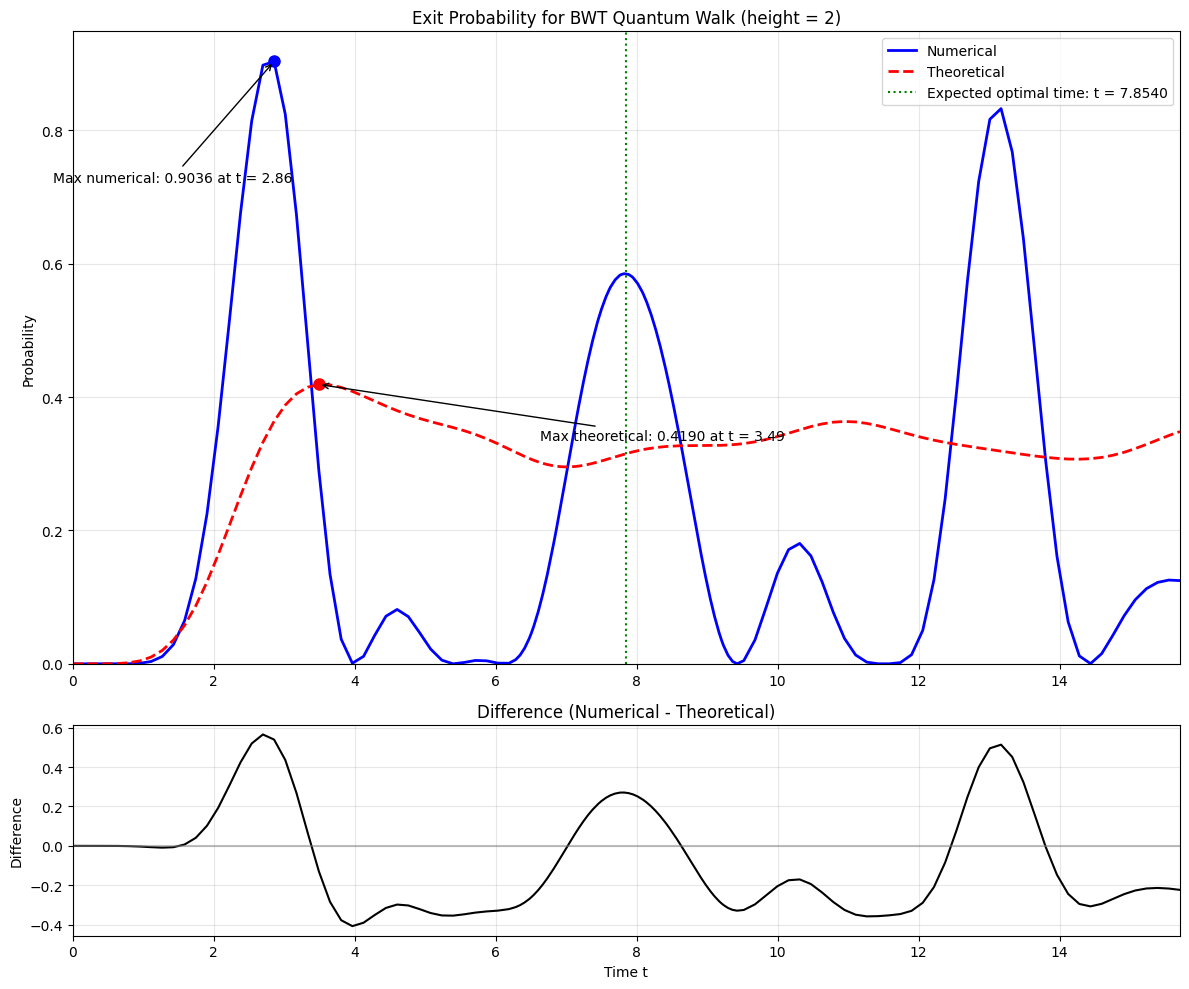

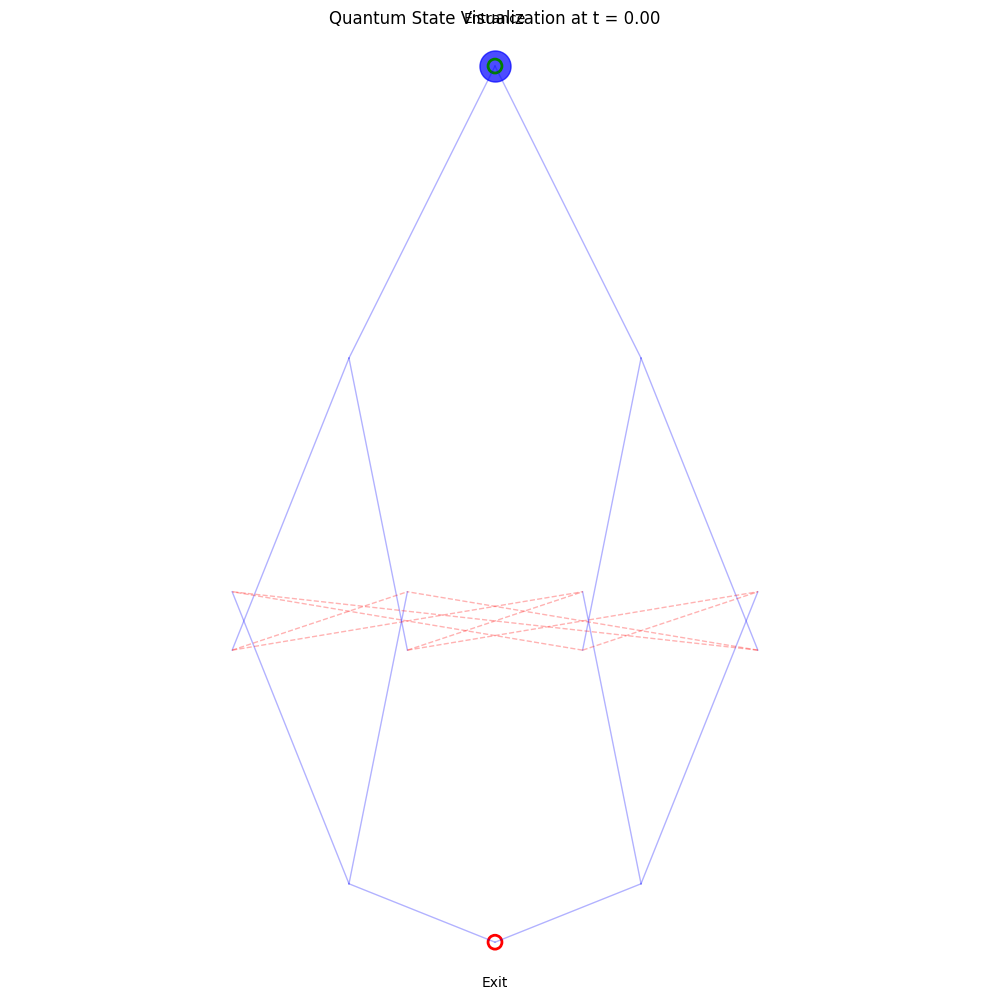

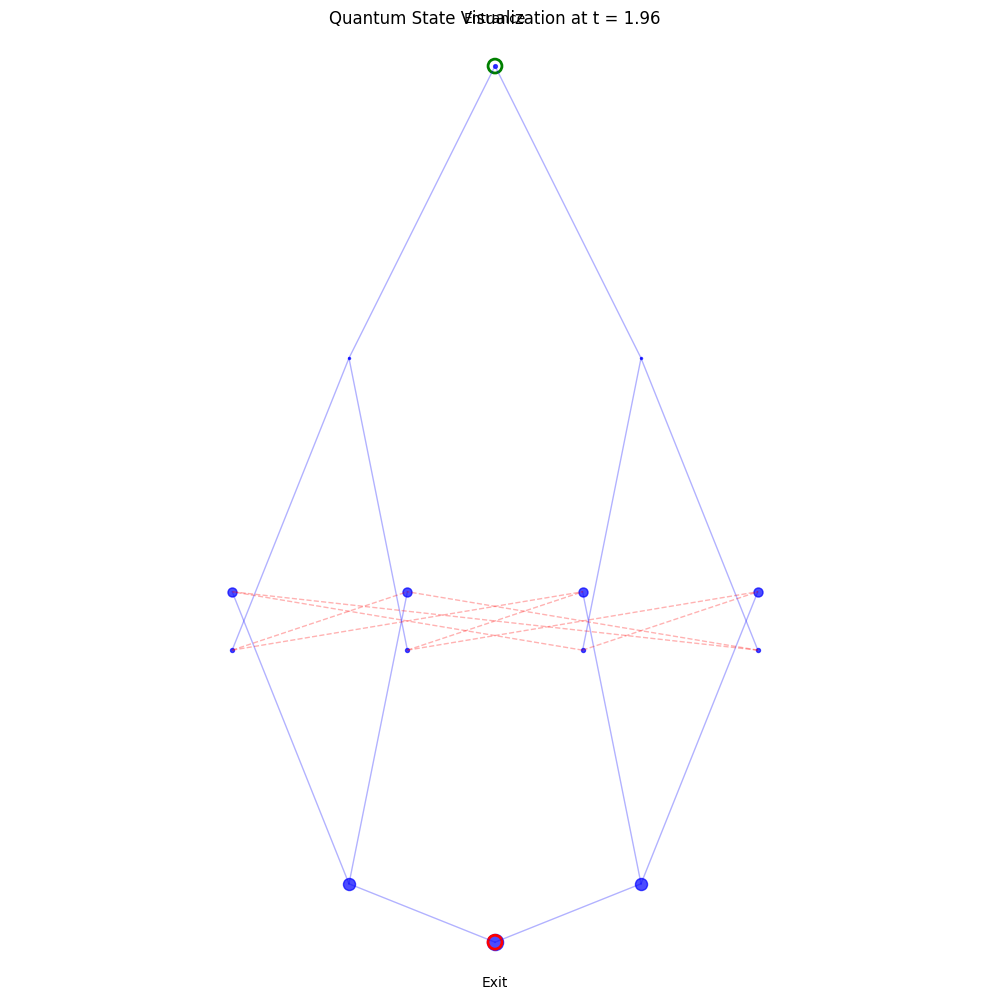

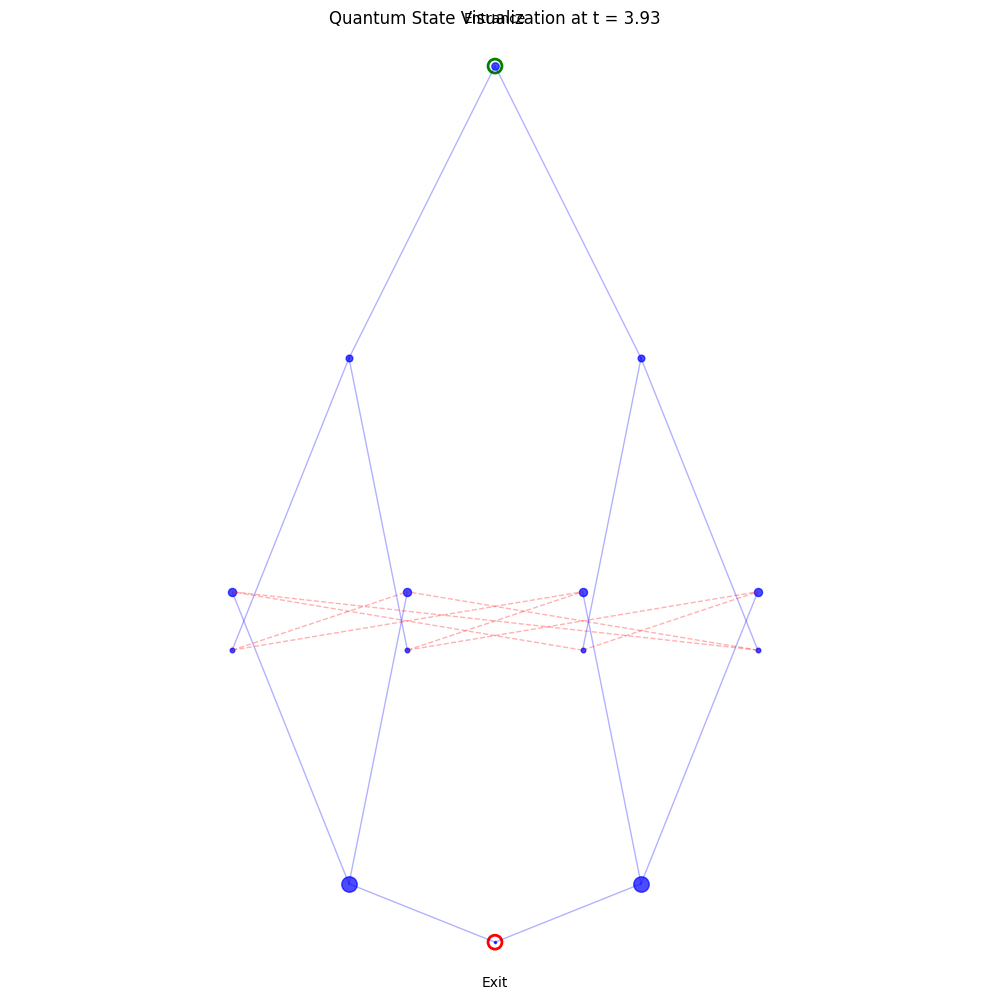

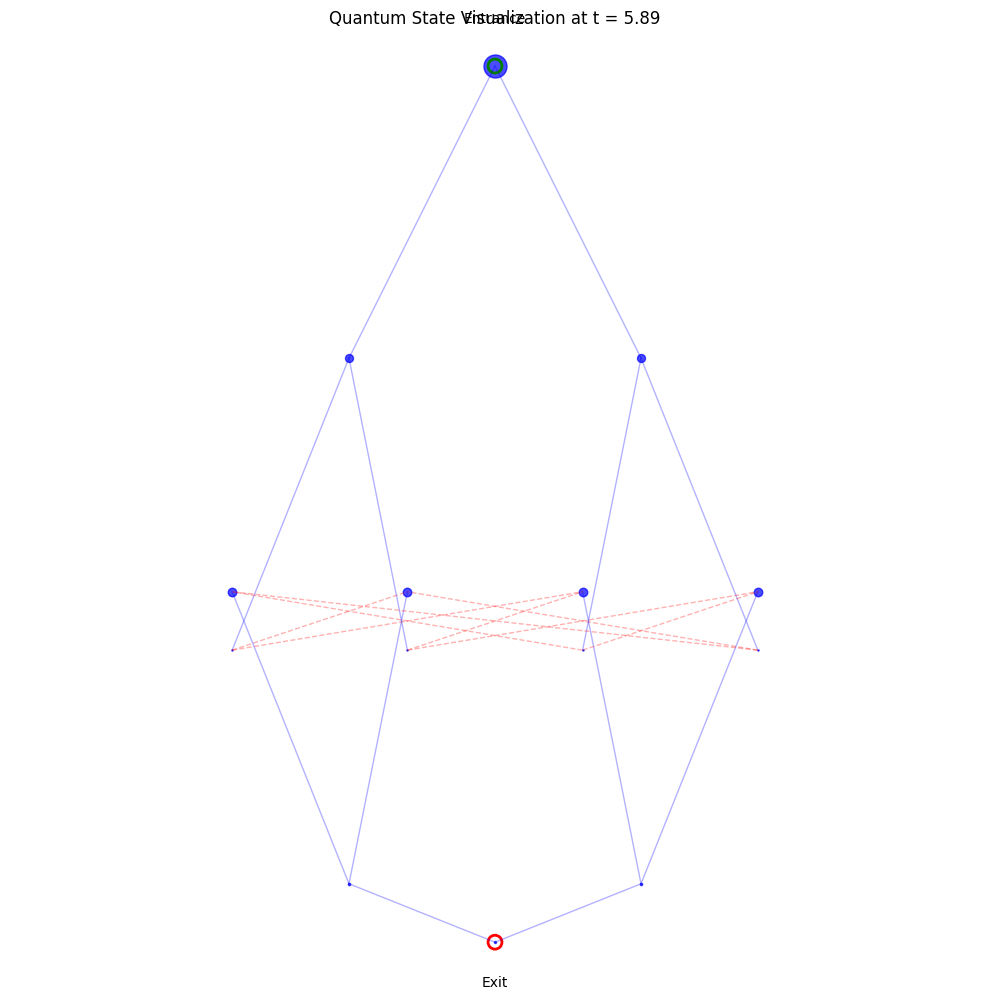

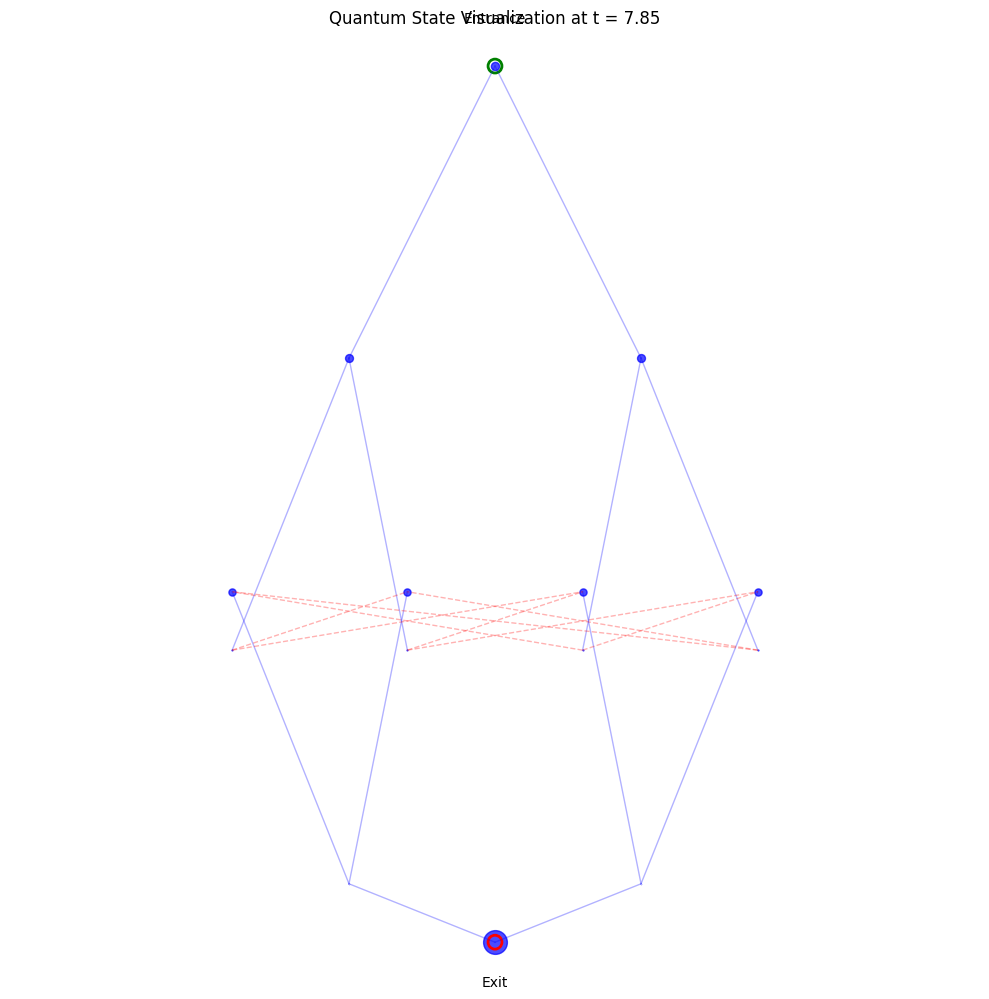

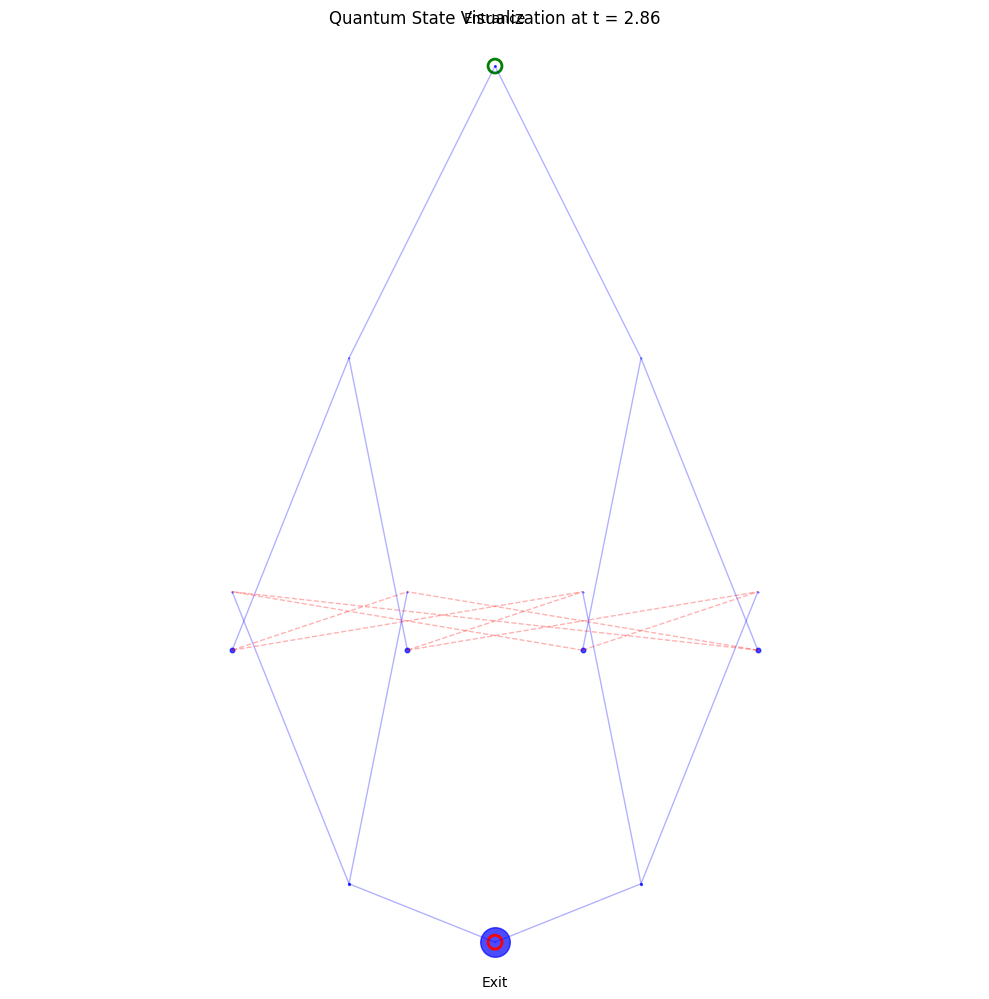

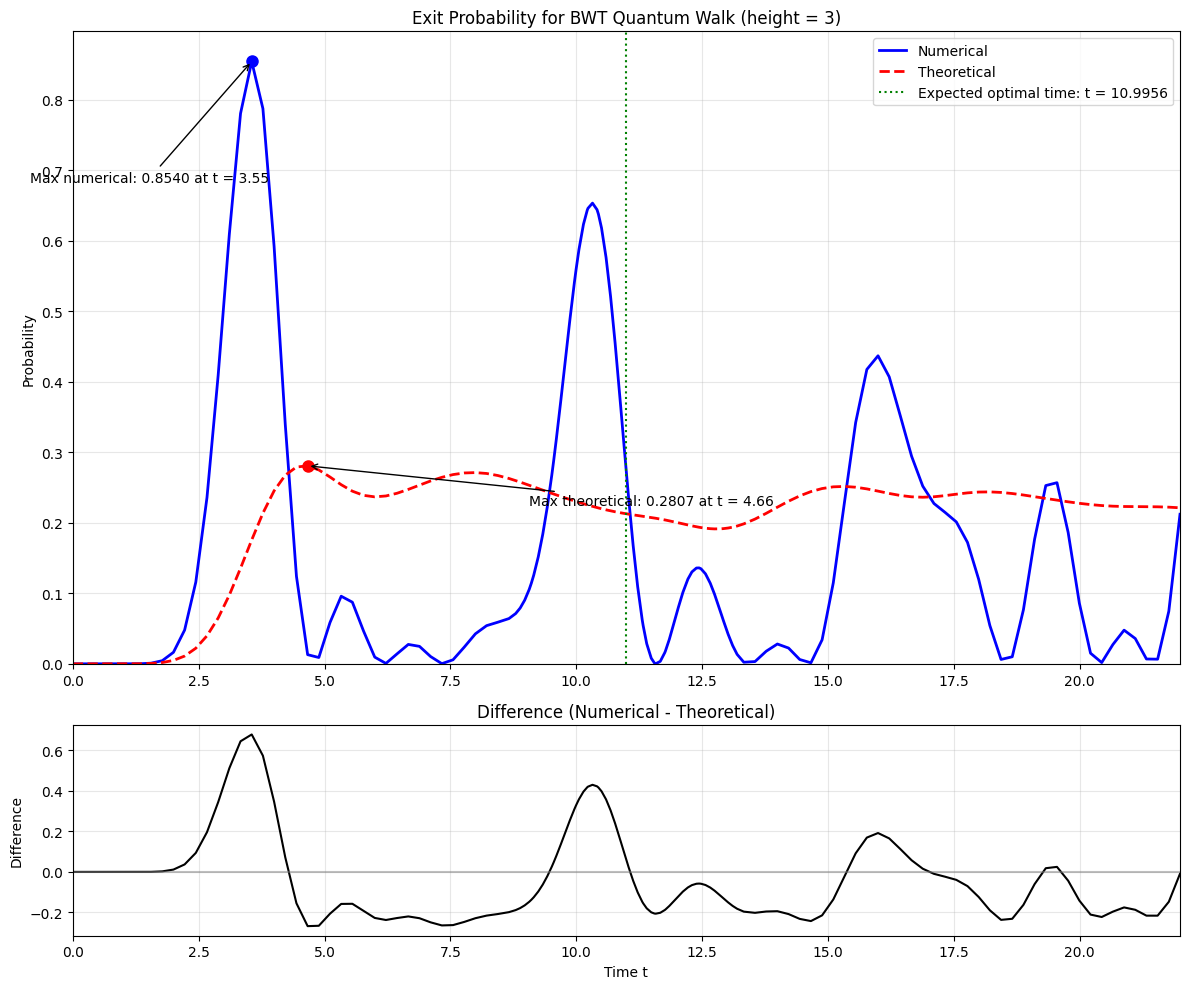

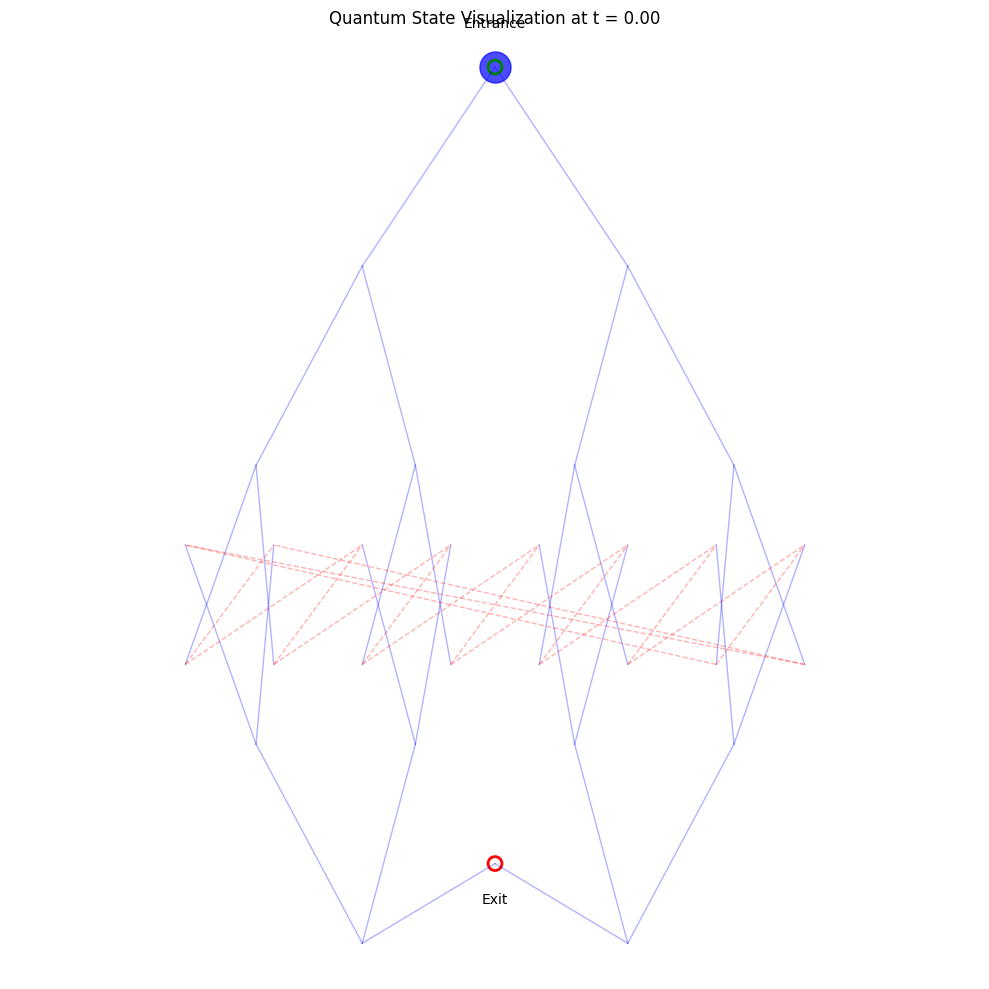

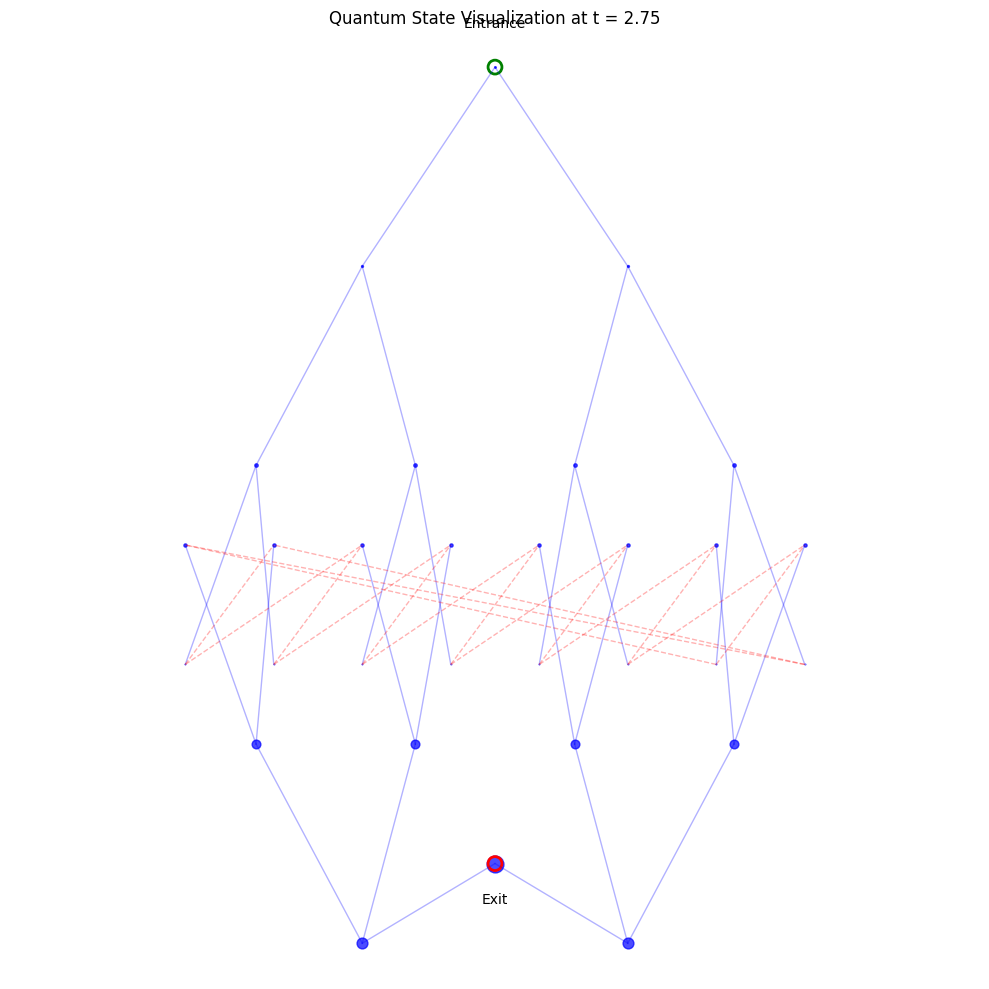

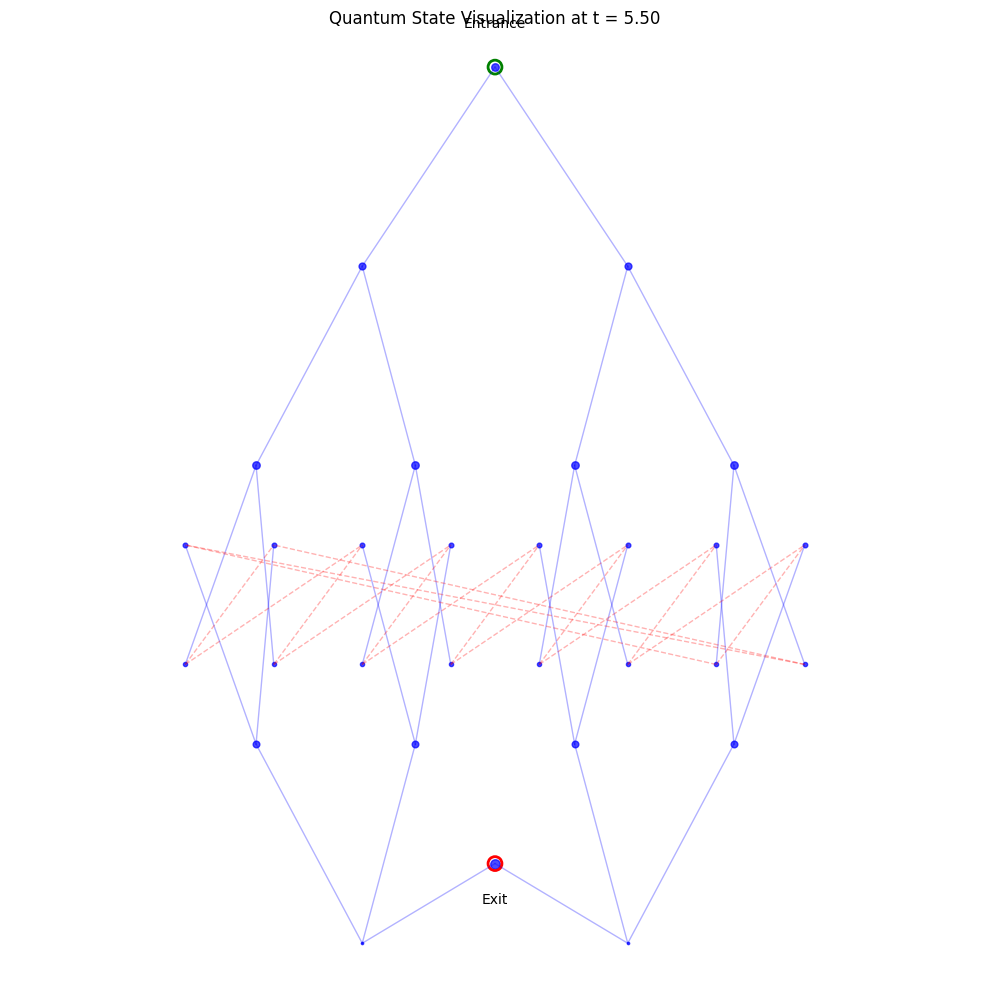

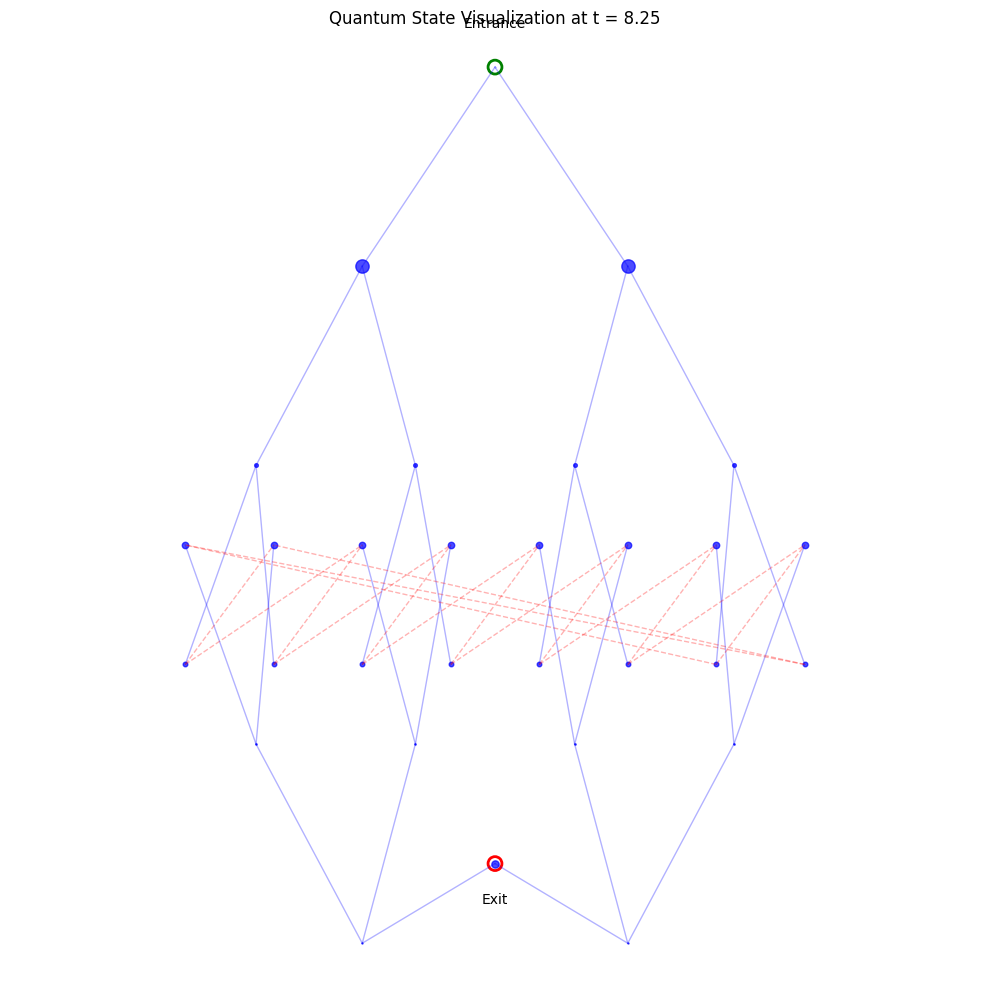

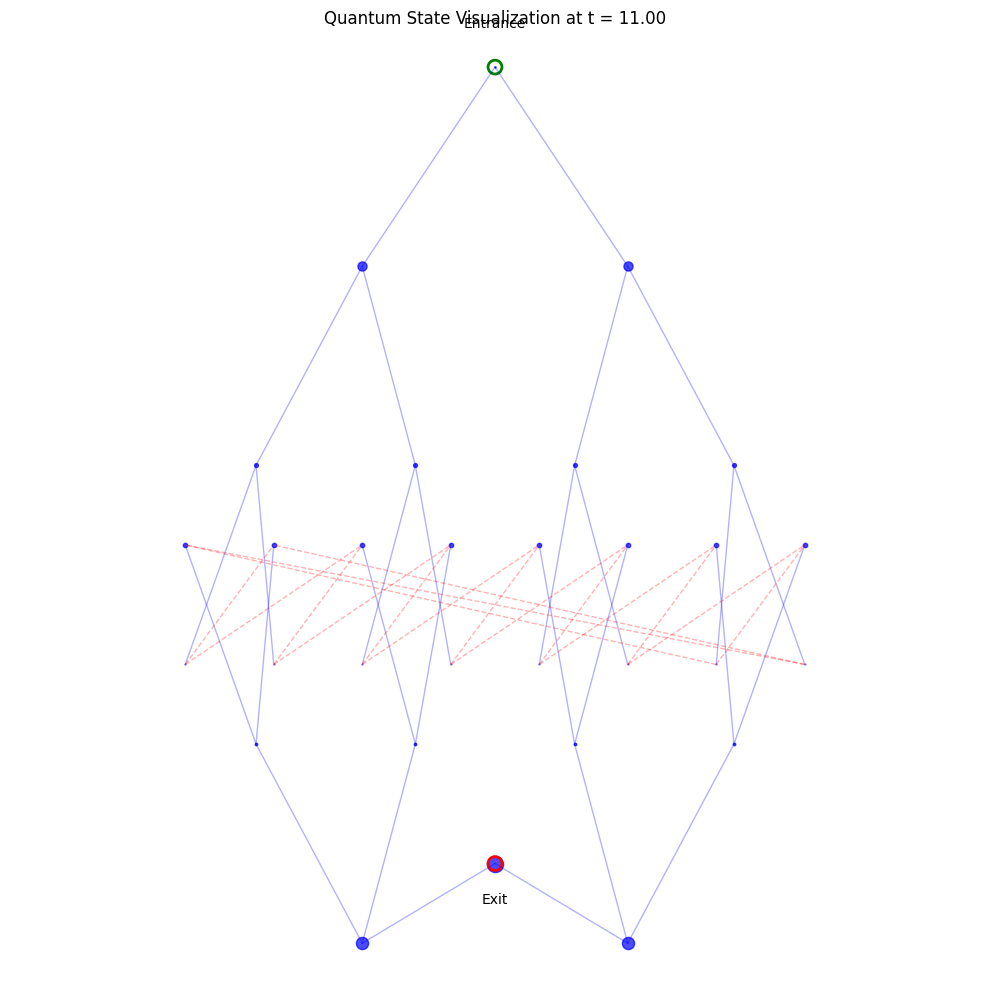

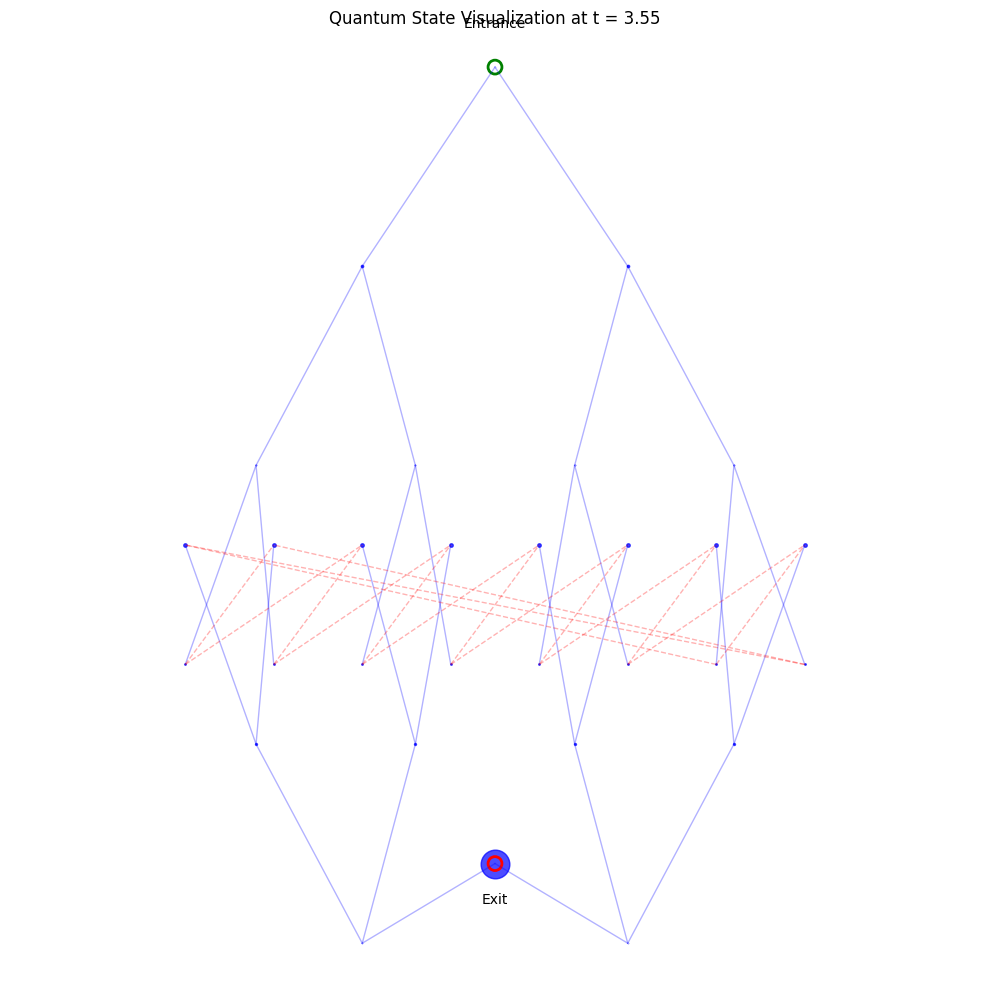

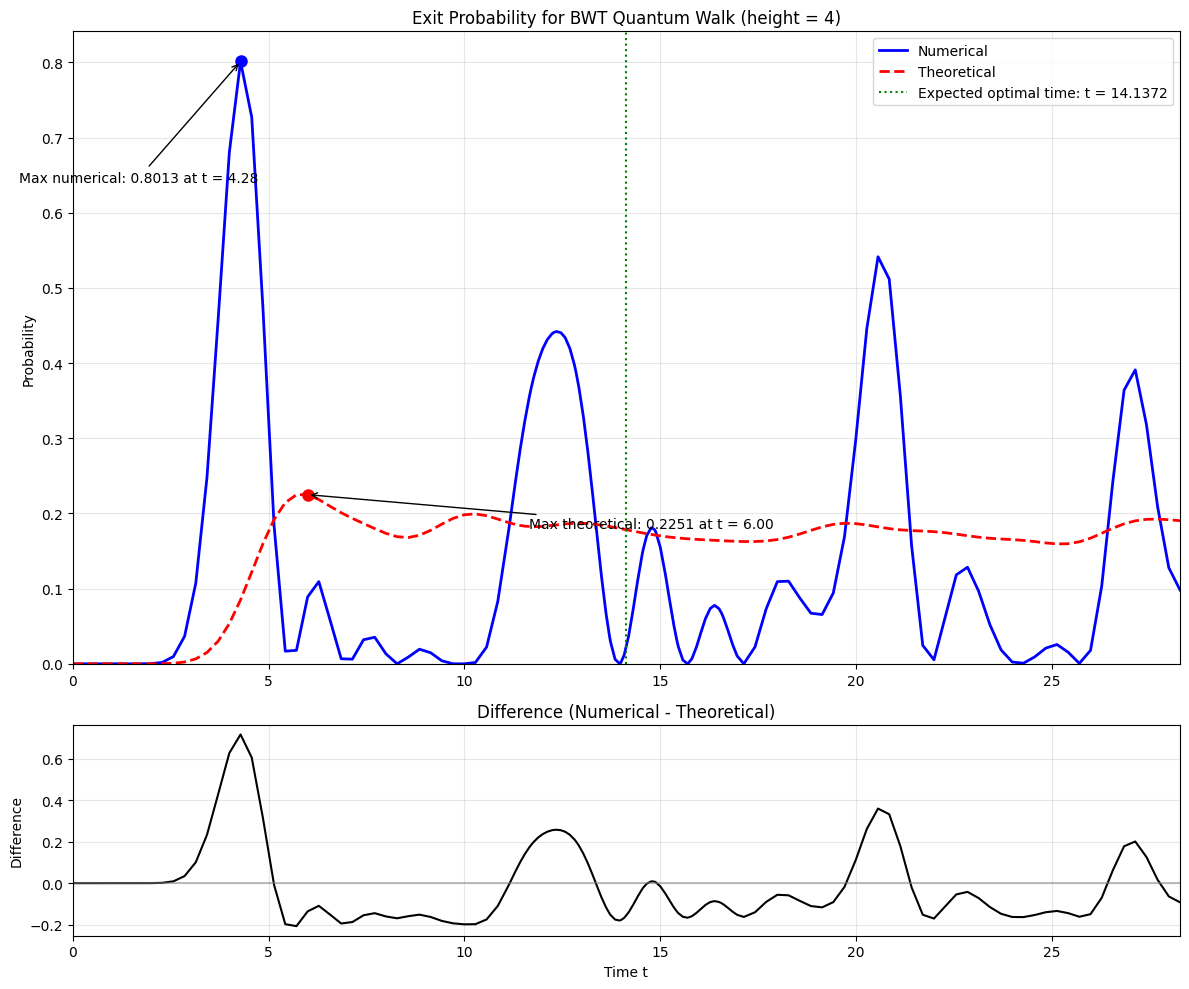

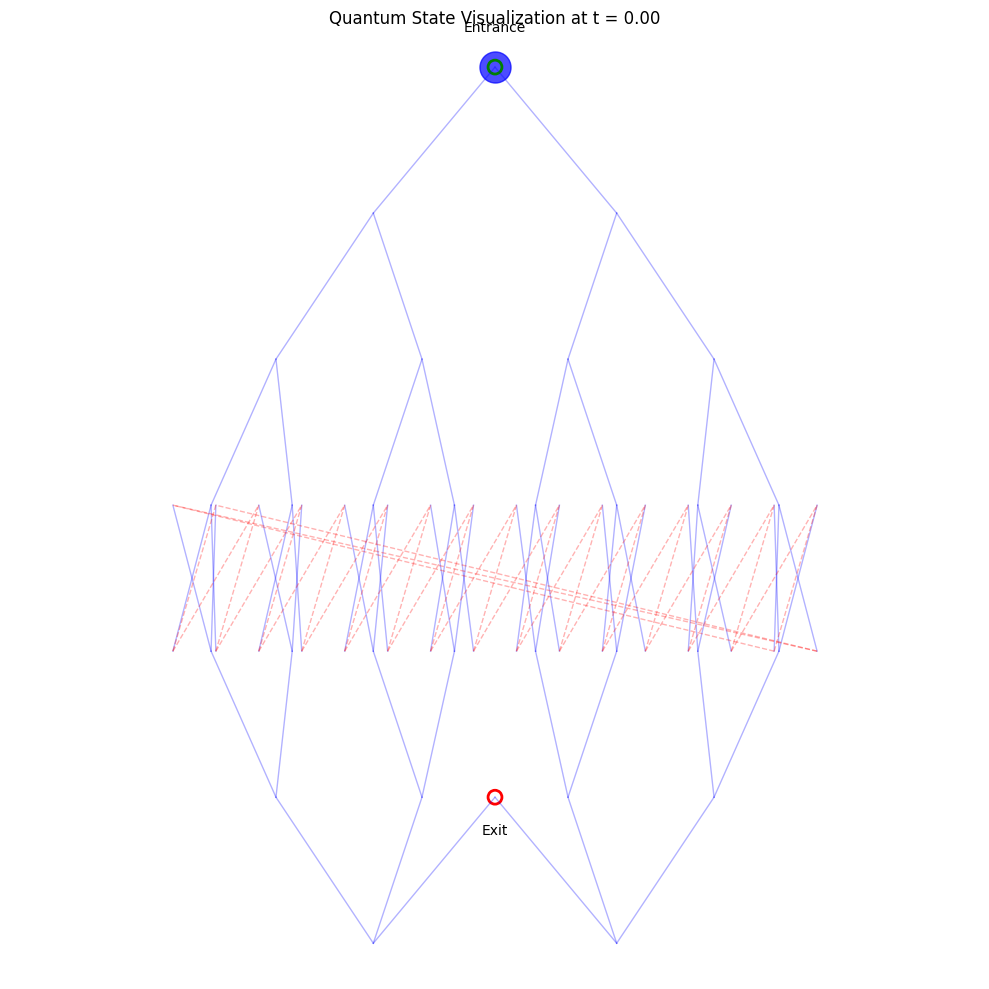

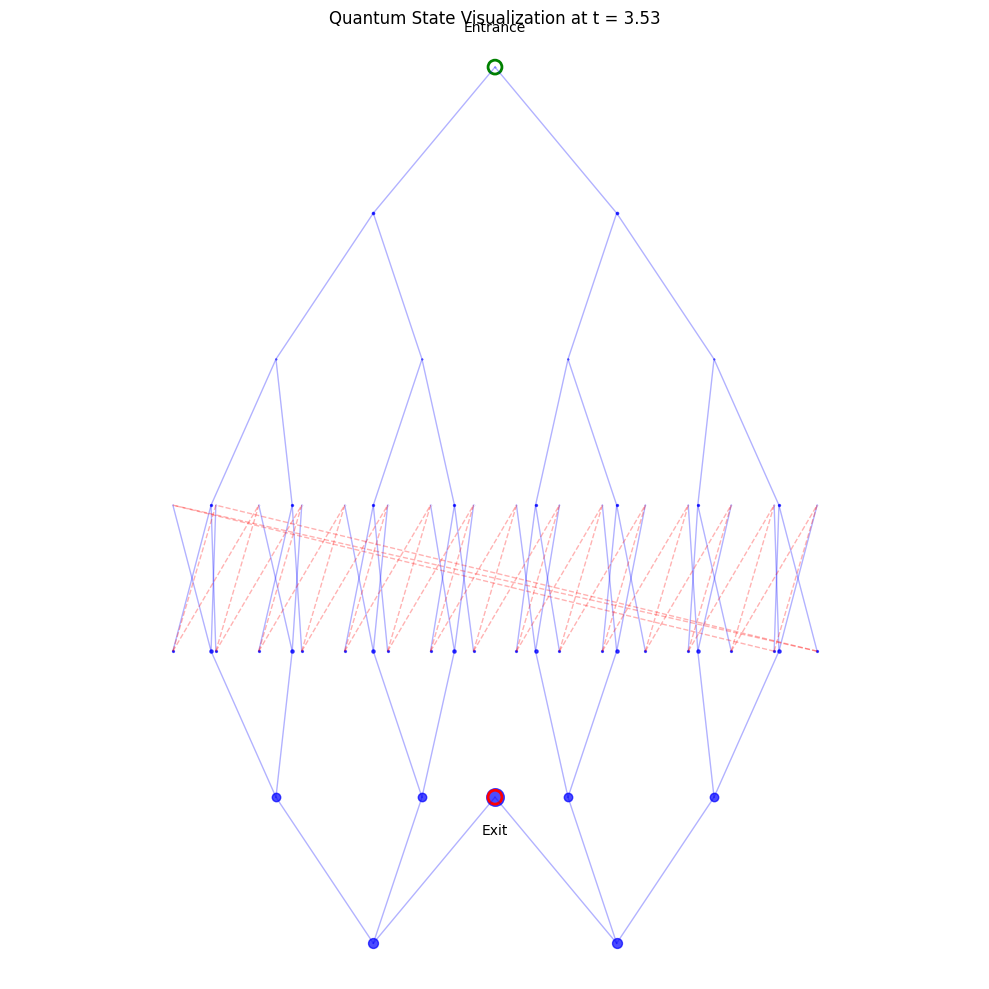

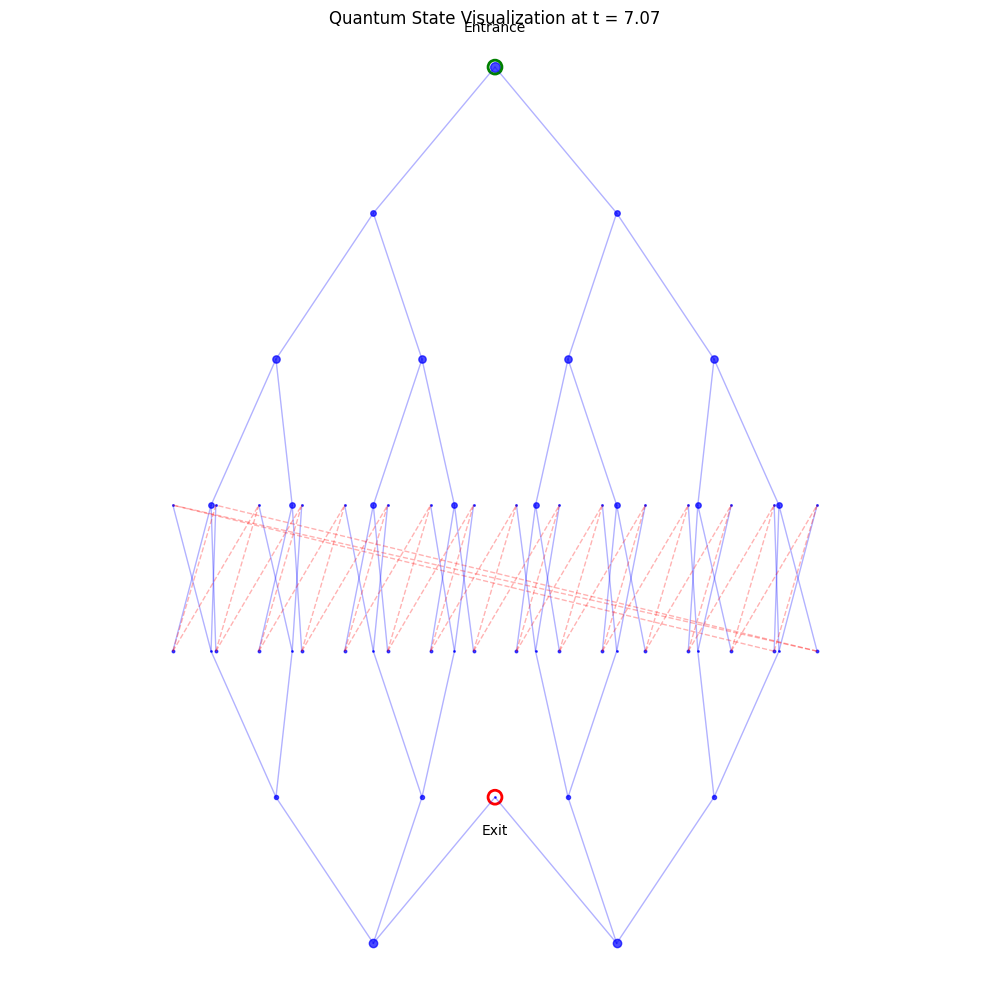

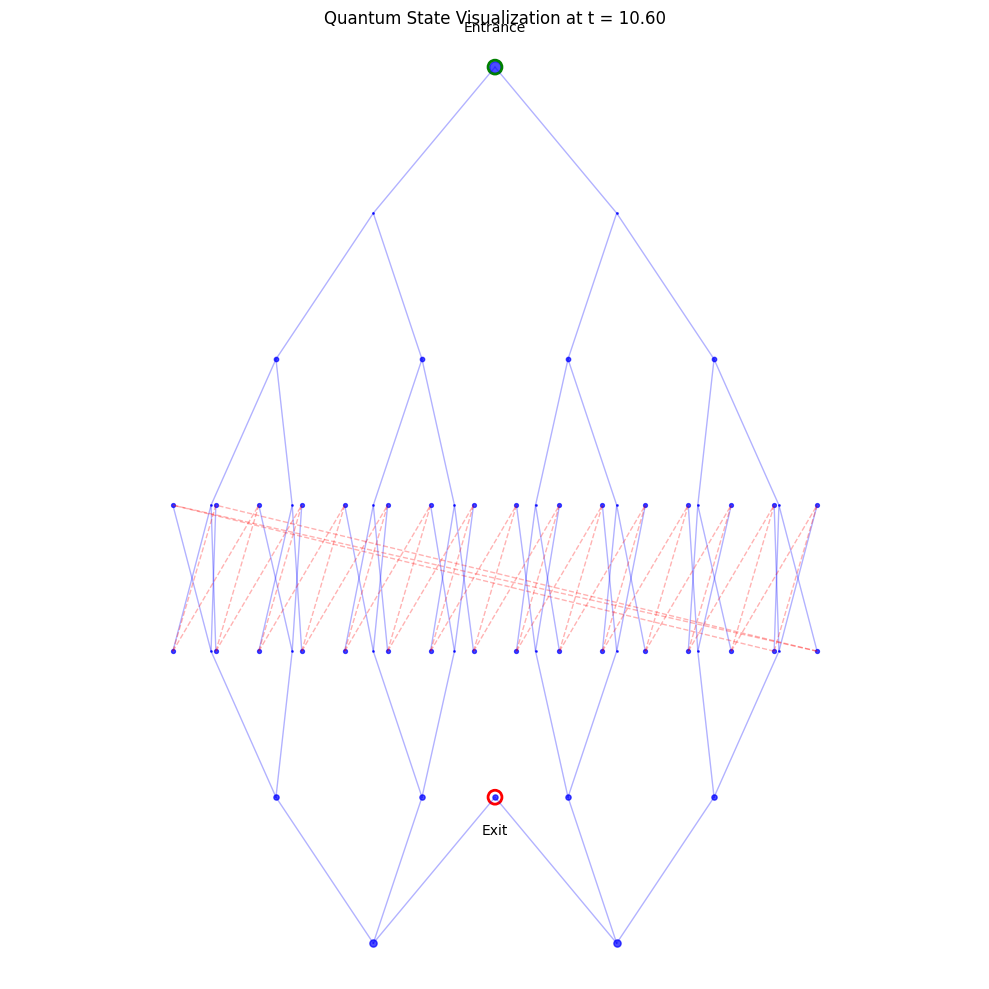

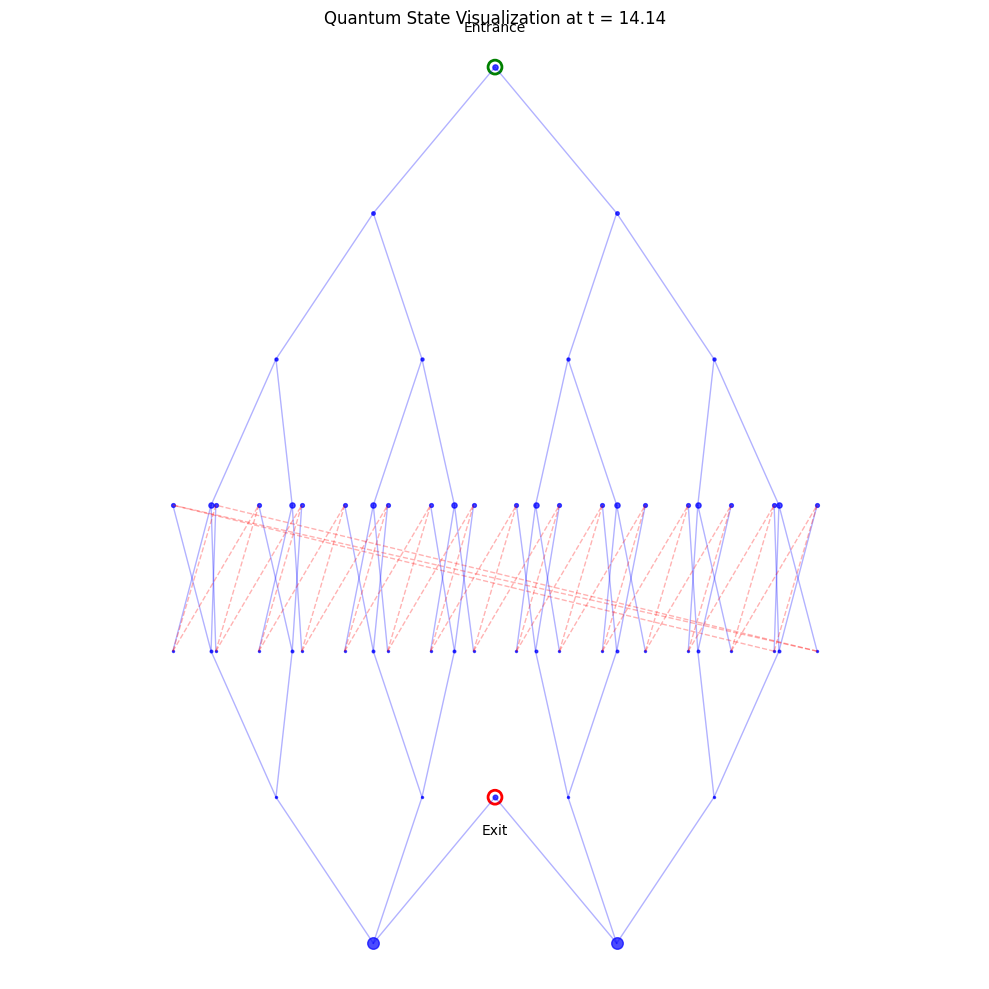

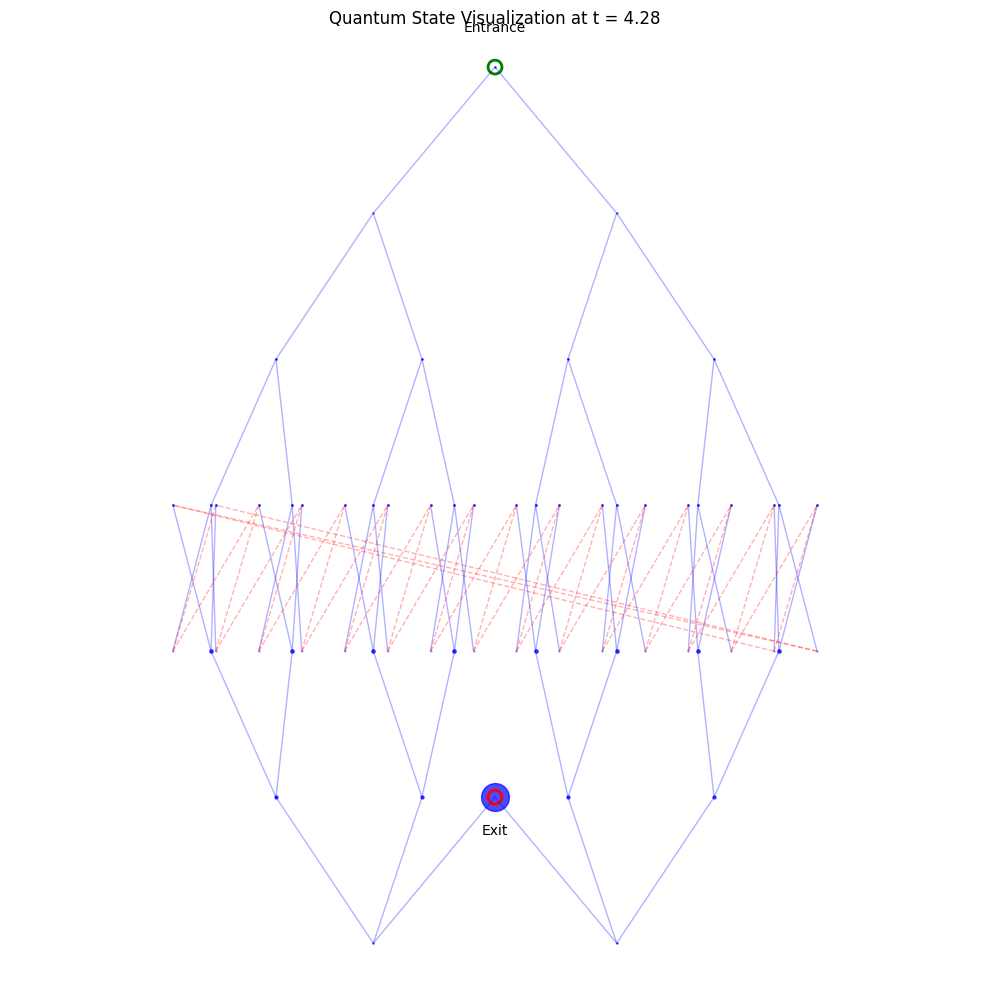

In [3]:
start_time = time.time()
main()
elapsed = time.time() - start_time
print(f"\nTotal execution time: {elapsed:.2f} seconds")